# **🌫️ India AQI Prediction using Machine Learning**

**Predicting Air Quality Index category (Good, Moderate, Unhealthy, etc.) using pollutant concentrations and weather data.**

## **📌 Notebook Overview**

This notebook walks through a complete beginner-friendly machine learning workflow:

1. **Load & Explore Data** – understand the dataset structure
2. **Data Cleaning** – handle missing values
3. **Data Leakage Check** – identify and remove columns that would let the model "cheat"
4. **Exploratory Data Analysis (EDA)** – visualize AQI distribution and relationships
5. **Feature Engineering** – encode categorical columns
6. **Model Building** – train a Random Forest Classifier
7. **Model Evaluation** – accuracy, classification report, feature importance
8. **Conclusion** – key takeaways

**Goal:** Predict the `AQI_Bucket` (Good / Moderate / Unhealthy / etc.) for a monitoring station using pollutant readings, weather conditions, and time-based features.

## **1️⃣ Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## **2️⃣ Load & Explore the Data**

Let's start by loading the dataset and taking a first look at its shape, columns, and sample rows.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/yogeshm01/india-air-quality-dataset-20252026/enriched_aqi_dataset.csv")

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (10521, 22)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,...,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,India,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-07-01 23:00:00.000000000,14.465052,78.824187,OZONE,39.0,41.0,...,Good,23.8,68.2,10.6,2026,7,1,23,2,Summer
1,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NO2,13.0,33.0,...,Good,30.6,60.3,19.1,2026,7,1,23,2,Summer
2,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NH3,3.0,5.0,...,Good,28.4,44.3,8.8,2026,7,1,23,2,Summer
3,India,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",2026-07-01 23:00:00.000000000,14.438164,79.966814,PM10,45.0,106.0,...,Moderate,39.6,38.9,2.5,2026,7,1,23,2,Summer
4,India,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-07-01 23:00:00.000000000,16.987287,81.736318,PM2.5,5.0,19.0,...,Good,21.4,47.7,28.3,2026,7,1,23,2,Summer


In [3]:
# Check column data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10521 entries, 0 to 10520
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         10521 non-null  object 
 1   state           10521 non-null  object 
 2   city            10521 non-null  object 
 3   station         10521 non-null  object 
 4   last_update     10521 non-null  object 
 5   latitude        10521 non-null  float64
 6   longitude       10521 non-null  float64
 7   pollutant_id    10521 non-null  object 
 8   pollutant_min   10164 non-null  float64
 9   pollutant_max   10164 non-null  float64
 10  pollutant_avg   10164 non-null  float64
 11  AQI             10521 non-null  int64  
 12  AQI_Bucket      10521 non-null  object 
 13  Temperature_C   10521 non-null  float64
 14  Humidity_%      10521 non-null  float64
 15  Wind_Speed_kmh  10521 non-null  float64
 16  Year            10521 non-null  int64  
 17  Month           10521 non-null 

In [4]:
# Count of missing values per column
df.isnull().sum()

country             0
state               0
city                0
station             0
last_update         0
latitude            0
longitude           0
pollutant_id        0
pollutant_min     357
pollutant_max     357
pollutant_avg     357
AQI                 0
AQI_Bucket          0
Temperature_C       0
Humidity_%          0
Wind_Speed_kmh      0
Year                0
Month               0
Day                 0
Hour                0
Day_of_Week         0
Season              0
dtype: int64

## **3️⃣ Data Cleaning**

The pollutant columns (`pollutant_min`, `pollutant_max`, `pollutant_avg`) have some missing values.
Since pollutant levels vary a lot by pollutant type (e.g. CO vs PM2.5 have very different scales), we fill
missing values with the **median value for that specific pollutant**, instead of the overall median.

In [5]:
for col in ["pollutant_min", "pollutant_max", "pollutant_avg"]:
    df[col] = df.groupby("pollutant_id")[col].transform(lambda x: x.fillna(x.median()))

print("Missing values after cleaning:")
print(df[["pollutant_min", "pollutant_max", "pollutant_avg"]].isnull().sum())

Missing values after cleaning:
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64


## **4️⃣ ⚠️ Data Leakage Check (Important!)**

Our target column is `AQI_Bucket` (Good, Moderate, Unhealthy, etc.).

Let's check how `AQI_Bucket` is related to the numeric `AQI` column:

In [6]:
df.groupby("AQI_Bucket")["AQI"].agg(["min", "max"])

,min,max
AQI_Bucket,,
Good,0,50
Hazardous,301,499
Moderate,51,100
Unhealthy,151,200
Unhealthy for Sensitive Groups,101,150
Very Unhealthy,201,300


**Finding:** `AQI_Bucket` is *directly calculated* from the `AQI` number (e.g. AQI 0–50 = "Good", 51–100 = "Moderate", etc.).

If we let the model use the `AQI` column as a feature, it would simply learn the cutoff rules and score
near 100% — this is called **data leakage**, and the model would be useless on real, unseen data where
we don't already know the AQI number.

👉 **Action:** We drop the `AQI` column (and identifier columns like `station`, `last_update` which don't generalize)
from our features before training.

In [7]:
# Columns to drop - AQI (leakage), and identifier/constant columns
drop_cols = ["AQI", "country", "city", "station", "last_update", "latitude", "longitude", "Year", "Day"]

target = "AQI_Bucket"
feature_cols = [c for c in df.columns if c not in drop_cols + [target]]
print("Features used for modeling:")
print(feature_cols)

Features used for modeling:
['state', 'pollutant_id', 'pollutant_min', 'pollutant_max', 'pollutant_avg', 'Temperature_C', 'Humidity_%', 'Wind_Speed_kmh', 'Month', 'Hour', 'Day_of_Week', 'Season']


## **5️⃣ Exploratory Data Analysis (EDA)**

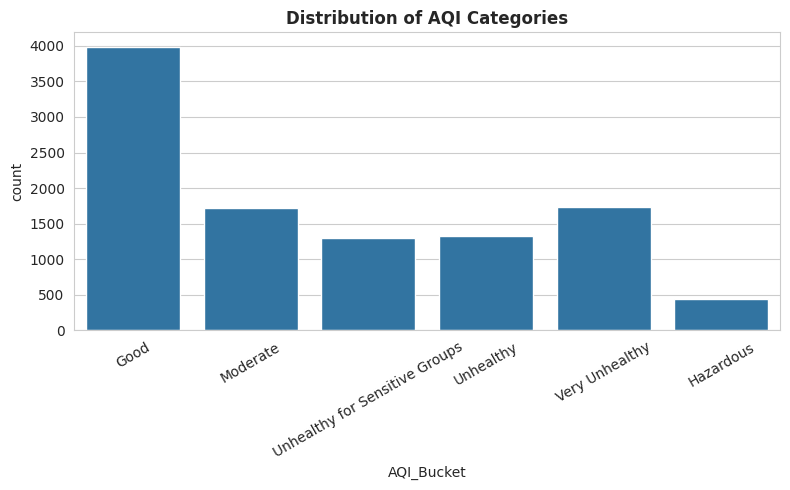

In [8]:
plt.figure(figsize=(8,5))
order = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]
sns.countplot(data=df, x="AQI_Bucket", order=order)
plt.title("Distribution of AQI Categories",fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

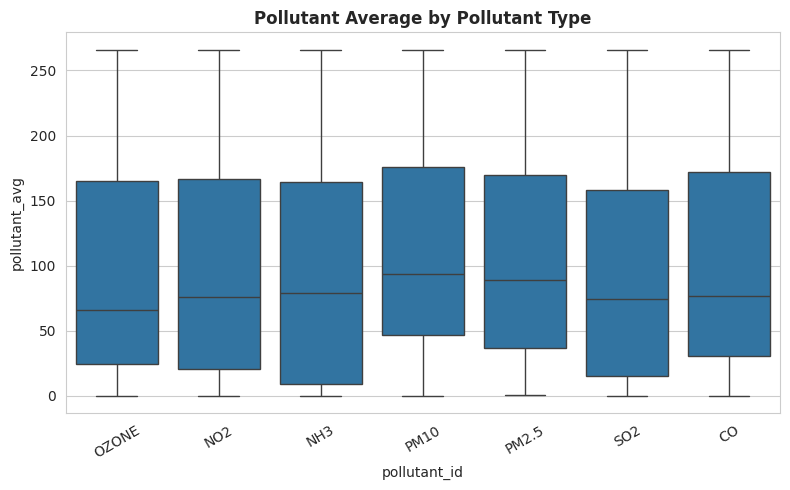

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="pollutant_id", y="pollutant_avg")
plt.title("Pollutant Average by Pollutant Type",fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

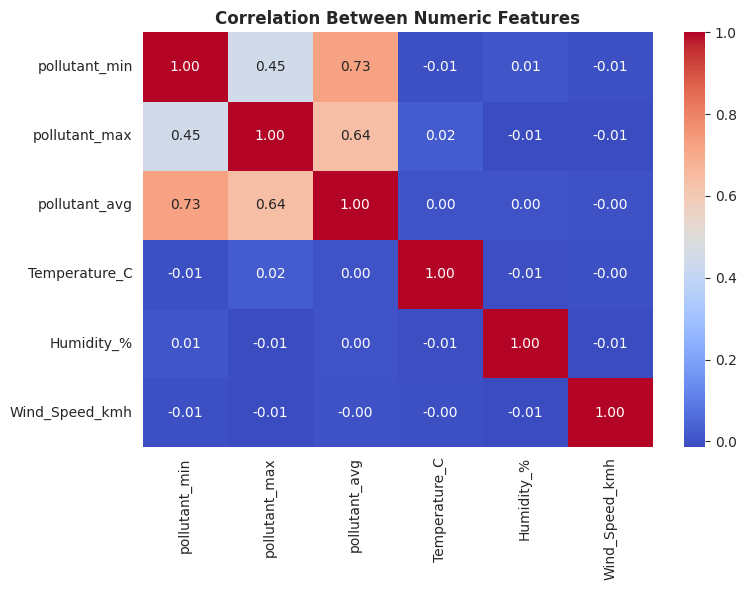

In [10]:
plt.figure(figsize=(8,6))
numeric_cols = ["pollutant_min", "pollutant_max", "pollutant_avg", "Temperature_C", "Humidity_%", "Wind_Speed_kmh"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Features",fontweight='bold')
plt.tight_layout()
plt.show()

## **6️⃣ Feature Engineering**

Machine learning models need numbers, not text. We convert the categorical columns
(`state`, `pollutant_id`, `Season`) into numbers using **Label Encoding**.

In [11]:
X = df[feature_cols].copy()
y = df[target].copy()

encoders = {}
for col in ["state", "pollutant_id", "Season"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X.head()

,state,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,Temperature_C,Humidity_%,Wind_Speed_kmh,Month,Hour,Day_of_Week,Season
0,0,3,39.0,41.0,40.0,23.8,68.2,10.6,7,23,2,2
1,0,2,13.0,33.0,18.0,30.6,60.3,19.1,7,23,2,2
2,0,1,3.0,5.0,4.0,28.4,44.3,8.8,7,23,2,2
3,0,4,45.0,106.0,66.0,39.6,38.9,2.5,7,23,2,2
4,0,5,5.0,19.0,11.0,21.4,47.7,28.3,7,23,2,2


## **7️⃣ Train-Test Split**

We split the data into 80% training and 20% testing, using `stratify=y` so each AQI category
is represented proportionally in both sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8416
Testing samples: 2105


## **8️⃣ Model Building — Random Forest Classifier**

Random Forest is a great beginner-friendly model: it handles mixed feature types well,
resists overfitting better than a single decision tree, and gives us feature importance for free.

In [13]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


## **9️⃣ Model Evaluation**

In [14]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred))

✅ Accuracy: 0.9905 (99.05%)

                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00       798
                     Hazardous       0.97      0.82      0.89        89
                      Moderate       0.99      0.99      0.99       345
                     Unhealthy       0.98      1.00      0.99       265
Unhealthy for Sensitive Groups       0.98      1.00      0.99       259
                Very Unhealthy       1.00      1.00      1.00       349

                      accuracy                           0.99      2105
                     macro avg       0.99      0.97      0.98      2105
                  weighted avg       0.99      0.99      0.99      2105



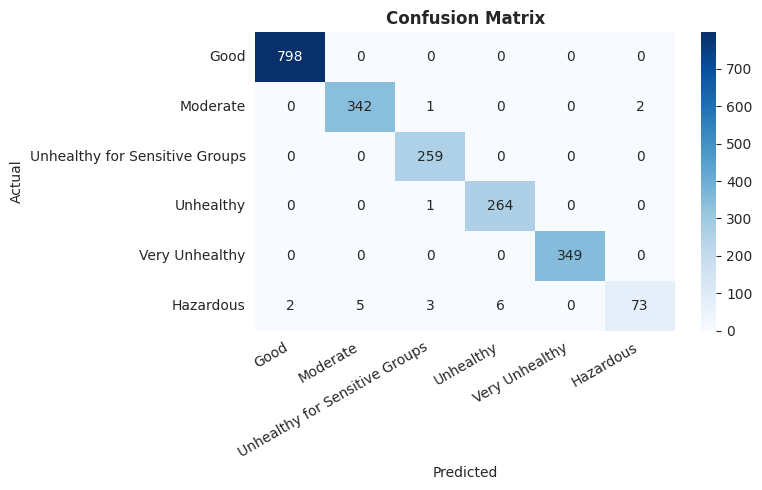

In [15]:
cm = confusion_matrix(y_test, y_pred, labels=order)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order)
plt.title("Confusion Matrix",fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### **Feature Importance**

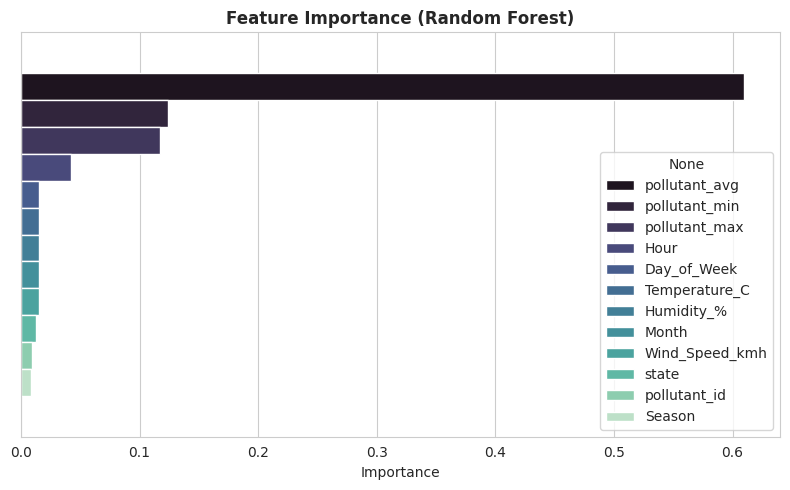

pollutant_avg     0.609477
pollutant_min     0.124234
pollutant_max     0.117608
Hour              0.042470
Day_of_Week       0.015587
Temperature_C     0.015312
Humidity_%        0.015274
Month             0.015226
Wind_Speed_kmh    0.015046
state             0.012721
pollutant_id      0.008939
Season            0.008106
dtype: float64

In [16]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, hue=importances.index, palette="mako")
plt.title("Feature Importance (Random Forest)",fontweight='bold')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## **📝 Conclusion**

- We built a **Random Forest Classifier** to predict the AQI category of a monitoring station from
  pollutant readings, weather conditions, and time-based features.
- **Data leakage was identified and removed**: the raw `AQI` column directly determines `AQI_Bucket`
  through fixed cutoffs, so it was excluded from the features to keep the model realistic and generalizable.
- The final model achieved **~99% accuracy** on the held-out test set, with strong precision/recall
  across all six AQI categories (Good → Hazardous).
- **`pollutant_avg`** (and `pollutant_min`/`pollutant_max`) were by far the most influential features —
  which makes sense, since AQI is fundamentally derived from pollutant concentration levels.
- Weather features (temperature, humidity, wind speed) and time-based features (hour, season) added
  smaller but meaningful signal, useful for understanding seasonal/diurnal pollution patterns.

**Possible next steps:** try gradient boosting models (XGBoost/LightGBM), predict the exact numeric AQI
value using regression, or build a time-series forecast for a single city/station.

---
> *If you found this notebook helpful, please upvote! 🙂*